# Applied Validation: Power-Flow Stress and Expansion Costs

The joint SWF + ÜZW run (`joint_setup.RUN_ID`) in the status quo and after electrification without HEMS
(INFLEX) and with HEMS, for the synthetic and the real grids. The paper figure and tables pool the providers as
*Real* and *Synthetic*; the per-provider views are diagnostics only.

**Grid set.**
- Power flow: the grids with non-converged hours in at least 1 % of the hours of any case are left out of every
  case of their group (`joint_setup.MIN_FAILED_SHARE`).
- Expansion costs: in addition, every real grid whose cost is incomplete in one of the cases. The materialization
  gives no cost to a real grid with non-converged hours, because its P100 loading is unknown. All cases then cover
  the same grids. Both lists are shown below.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from gridexpand.analysis.expansion.notebook_workflow import (
    PROVIDER_LABELS,
    expansion_cost_comparison,
    expansion_cost_reduction_summary,
    expansion_grid_costs,
    export_scenario_analysis_manifest,
    group_network,
    load_cable_loading_decomposition,
    load_powerflow_cutoff_comparison,
    load_transformer_import_distributions_for_specs,
    load_voltage_summaries_for_powerflow_comparison,
)
from gridexpand.analysis.plotting.expansion_cost_plots import (
    plot_expansion_cost_overview_static,
    plot_expansion_cost_stacked_static,
)
from gridexpand.analysis.plotting.powerflow_asset_plots import (
    plot_cable_capacity_current_loading_comparison,
    plot_powerflow_asset_cutoff_overview_static,
)
from gridexpand.analysis.plotting.powerflow_transformer import plot_transformer_import_distributions_matplotlib
from gridexpand.analysis.plotting.powerflow_voltage import plot_voltage_deviation_histogram_comparison
from joint_setup import CASE_COLORS, CASE_DISPLAY, CURVE_Y_LIMITS, OUTPUT_DIR, STAGE_LABELS, prepare_joint_analysis

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

context = prepare_joint_analysis()
CASES = list(STAGE_LABELS.values())
PRE, INFLEX, HEMS = STAGE_LABELS["pre"], STAGE_LABELS["post_inflex"], STAGE_LABELS["post_flex"]
FIGURE_DIR = OUTPUT_DIR / "expansion"
export_scenario_analysis_manifest(context, output_dir=FIGURE_DIR, excluded_grids=context["excluded_grids"])

{'manifest': PosixPath('/home/breveron/git/github/diss/SurroGrid/GridExpand/work/analysis/output/plots/joint_2045_internal_2k_a3/expansion/scenario_analysis_manifest.json'),
 'powerflow_readiness': PosixPath('/home/breveron/git/github/diss/SurroGrid/GridExpand/work/analysis/output/plots/joint_2045_internal_2k_a3/expansion/powerflow_readiness.csv'),
 'publication_gate': PosixPath('/home/breveron/git/github/diss/SurroGrid/GridExpand/work/analysis/output/plots/joint_2045_internal_2k_a3/expansion/publication_gate.csv')}

## Readiness

The gate checks the raw run: `compact power-flow runs complete` fails as long as any grid has non-converged hours,
also the grids excluded below.

In [2]:
display(context["powerflow_status"])
display(context["publication_gate"])
display(context["analysis_status"])
if not context["publication_ready"]:
    print("DIAGNOSTIC: at least one readiness check failed (see the gate above).")

,data_source,stage,run_name,expected_grids,launched_grids,summary_grids,pending_or_missing_summaries,grids_with_failed_timesteps,failed_timesteps,timestep_signatures,scenario_labels,profile_contracts,complete
0,Real SWF,status-quo,joint_2045_internal_2k_a3_swf_real_swf_pre,44,44,44,0,0,0,8760,joint_2045_internal_2k_a3_swf_post-hems-heuristic,physical_building_component_paired_v2,True
1,Real SWF,INFLEX,joint_2045_internal_2k_a3_swf_real_swf_post-in...,44,44,44,0,5,124,8760,joint_2045_internal_2k_a3_swf_post-hems-heuristic,physical_building_component_paired_v2,False
2,Real SWF,HEMS,joint_2045_internal_2k_a3_swf_real_swf_post-he...,44,44,44,0,1,1,8760,joint_2045_internal_2k_a3_swf_post-hems-heuristic,physical_building_component_paired_v2,False
3,Synthetic SWF,status-quo,joint_2045_internal_2k_a3_swf_synthetic_pre,45,45,45,0,0,0,8760,joint_2045_internal_2k_a3_swf_post-hems-heuristic,physical_building_component_paired_v2,True
4,Synthetic SWF,INFLEX,joint_2045_internal_2k_a3_swf_synthetic_post-i...,45,45,45,0,0,0,8760,joint_2045_internal_2k_a3_swf_post-hems-heuristic,physical_building_component_paired_v2,True
5,Synthetic SWF,HEMS,joint_2045_internal_2k_a3_swf_synthetic_post-h...,45,45,45,0,0,0,8760,joint_2045_internal_2k_a3_swf_post-hems-heuristic,physical_building_component_paired_v2,True
6,Real ÜZW,status-quo,joint_2045_internal_2k_a3_uzw_real_uzw_pre,213,213,213,0,0,0,8760,joint_2045_internal_2k_a3_uzw_post-hems-heuristic,physical_building_component_paired_v2,True
7,Real ÜZW,INFLEX,joint_2045_internal_2k_a3_uzw_real_uzw_post-in...,213,213,213,0,0,0,8760,joint_2045_internal_2k_a3_uzw_post-hems-heuristic,physical_building_component_paired_v2,True
8,Real ÜZW,HEMS,joint_2045_internal_2k_a3_uzw_real_uzw_post-he...,213,213,213,0,0,0,8760,joint_2045_internal_2k_a3_uzw_post-hems-heuristic,physical_building_component_paired_v2,True
9,Synthetic ÜZW,status-quo,joint_2045_internal_2k_a3_uzw_synthetic_pre,203,203,203,0,0,0,8760,joint_2045_internal_2k_a3_uzw_post-hems-heuristic,physical_building_component_paired_v2,True


,check,passed,detail
0,All 12 compact power-flow runs complete,False,1515 grid-stage summaries; 125 failed timesteps
1,Shared temporal horizon,True,8760
2,Scenario labels of this run,True,joint_2045_internal_2k_a3_swf_post-hems-heuris...
3,Single paired profile contract,True,physical_building_component_paired_v2
4,12 matching synthetic/real expansion materiali...,True,12/12 available
5,All materialized grid costs complete,True,0 incomplete and 0 explicitly excluded grid-st...


,stage_label,analysis_key,available,data_source,run_name,stage,grids_with_expansion_summary,grids_total,grids_complete,grids_incomplete,grids_excluded,total_cost_eur
0,status-quo,joint_2045_internal_2k_a3_swf_real_pre,True,Real SWF,joint_2045_internal_2k_a3_swf_real_swf_pre,pre,44,44,44,0,0,9.727000e+03
1,INFLEX,joint_2045_internal_2k_a3_swf_real_post_inflex,True,Real SWF,joint_2045_internal_2k_a3_swf_real_swf_post-in...,post,44,44,44,0,0,3.976862e+06
2,HEMS,joint_2045_internal_2k_a3_swf_real_post,True,Real SWF,joint_2045_internal_2k_a3_swf_real_swf_post-he...,post,44,44,44,0,0,2.095138e+06
3,status-quo,joint_2045_internal_2k_a3_swf_synthetic_pre,True,Synthetic SWF,joint_2045_internal_2k_a3_swf_synthetic_pre,pre,45,45,45,0,0,0.000000e+00
4,INFLEX,joint_2045_internal_2k_a3_swf_synthetic_post_i...,True,Synthetic SWF,joint_2045_internal_2k_a3_swf_synthetic_post-i...,post,45,45,45,0,0,3.467150e+06
5,HEMS,joint_2045_internal_2k_a3_swf_synthetic_post,True,Synthetic SWF,joint_2045_internal_2k_a3_swf_synthetic_post-h...,post,45,45,45,0,0,1.564726e+06
6,status-quo,joint_2045_internal_2k_a3_uzw_real_pre,True,Real ÜZW,joint_2045_internal_2k_a3_uzw_real_uzw_pre,pre,213,213,213,0,0,0.000000e+00
7,INFLEX,joint_2045_internal_2k_a3_uzw_real_post_inflex,True,Real ÜZW,joint_2045_internal_2k_a3_uzw_real_uzw_post-in...,post,213,213,213,0,0,1.147670e+06
8,HEMS,joint_2045_internal_2k_a3_uzw_real_post,True,Real ÜZW,joint_2045_internal_2k_a3_uzw_real_uzw_post-he...,post,213,213,213,0,0,8.729354e+05
9,status-quo,joint_2045_internal_2k_a3_uzw_synthetic_pre,True,Synthetic ÜZW,joint_2045_internal_2k_a3_uzw_synthetic_pre,pre,203,203,203,0,0,0.000000e+00


DIAGNOSTIC: at least one readiness check failed (see the gate above).


## Non-converged grids

In [3]:
display(context["nonconverged"])
context["excluded_grids"]

,data_source,network,provider,grid,grid_key,cases,max_failed_timesteps,n_timesteps,max_failed_share,excluded
0,Real SWF,Real,SWF,SWF LV_153,153,"INFLEX, HEMS",67,8760,0.007648,False
1,Real SWF,Real,SWF,SWF LV_073,73,INFLEX,30,8760,0.003425,False
2,Real SWF,Real,SWF,SWF LV_034,34,INFLEX,12,8760,0.001370,False
3,Real SWF,Real,SWF,SWF LV_054,54,INFLEX,11,8760,0.001256,False
4,Real SWF,Real,SWF,SWF LV_079,79,INFLEX,4,8760,0.000457,False


{}

## Power-flow stress (paper figure)

Figure *paired-asset-cutoff-overview*: mean stress over the retained grids by retained-grid cutoff (top) and the
distribution of each grid's critical asset at the P99 cutoff (bottom). Synthetic (left) and real grids (right) sit side
by side in each case, real lighter with a dashed outline. The dotted line is the status-quo median.

comparison_stage,status-quo,INFLEX,HEMS
data_source,,,
Real SWF,44,44,44
Real ÜZW,213,213,213
Synthetic SWF,45,45,45
Synthetic ÜZW,203,203,203


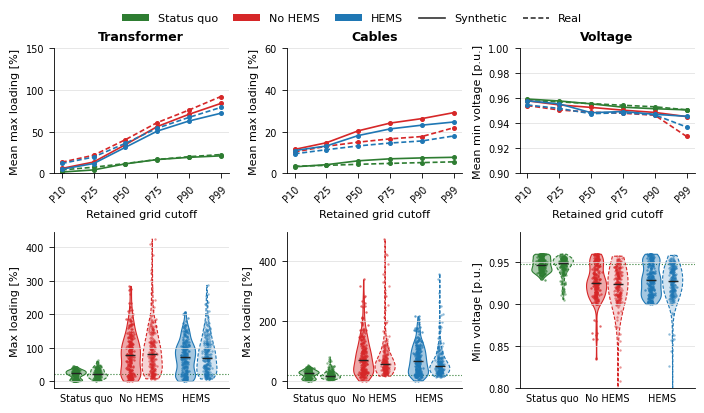

In [4]:
comparison = load_powerflow_cutoff_comparison(
    specs_by_source=context["specs_by_source"],
    stage_order=CASES,
    excluded_grids=context["excluded_grids"],
)
profile = comparison["profile"]
display(comparison["coverage_summary"].pivot(index="data_source", columns="comparison_stage", values="grids"))

OVERVIEW = dict(
    group_col="comparison_stage",
    source_col="network",
    color_map=CASE_COLORS,
    group_labels=CASE_DISPLAY,
    reference_group=PRE,
    asset_cutoff_percentile=0.99,
    asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
    filter_scope="grid",
    worst_asset_per_grid=True,
    curve_y_axis_limits=CURVE_Y_LIMITS,
    distribution_y_axis_limits={"Voltage": (0.80, None)},
)
fig = plot_powerflow_asset_cutoff_overview_static(
    profile, save_path=FIGURE_DIR / "pre_post_flex_no_flex_asset_cutoff_overview", **OVERVIEW
)
plt.show()

### Per provider (diagnostic; names the DSOs, not for publication)

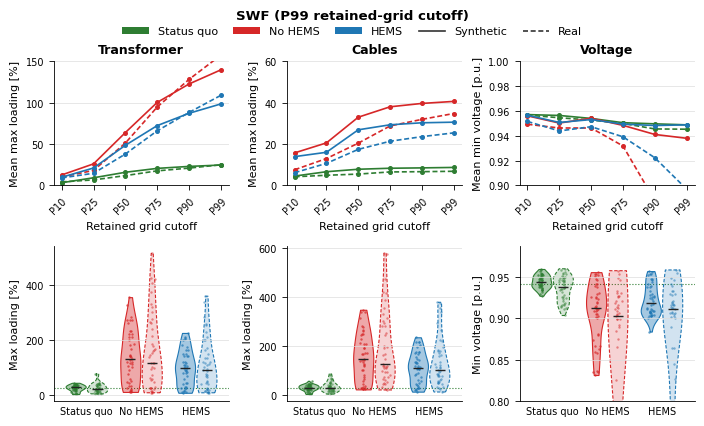

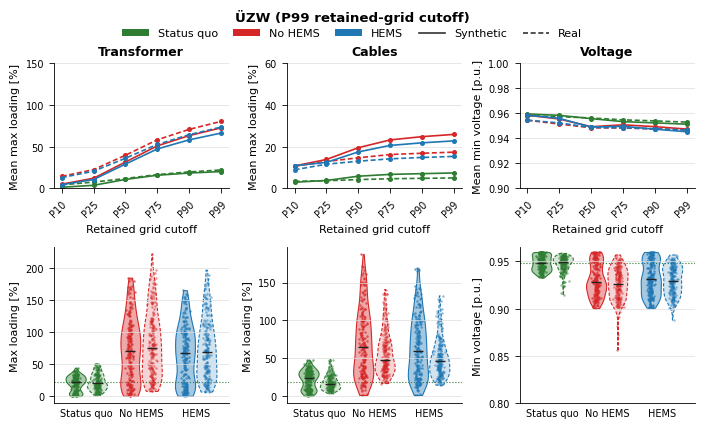

In [5]:
for provider in context["providers"]:
    label = PROVIDER_LABELS[provider]
    fig = plot_powerflow_asset_cutoff_overview_static(
        profile[profile["provider"] == label],
        title=label,
        save_path=FIGURE_DIR / f"pre_post_flex_no_flex_asset_cutoff_overview_{provider}",
        **OVERVIEW,
    )
    plt.show()

## Expansion costs

Staged LV rules (`de_lv_staged_2026`) per grid, summed over the common grid set of all cases. Figure
*expansion-cost-overview*: total per case with the HEMS change against INFLEX (left) and the cost per asset
in both electrified cases (right; the status quo costs nothing per asset), synthetic solid, real lighter with a
dashed outline. *Other*: load transfers to a neighbouring station with spare capacity (20 k€ per grid) and
voltage-regulating transformers (rONT) for buses still below 0.90 pu.

/home/breveron/git/github/diss/SurroGrid/GridExpand/src/gridexpand/analysis/expansion/notebook_workflow.py:261: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()


,data_source,grid,reason


grids                   total_cost_eur                           
stage         HEMS INFLEX status-quo           HEMS        INFLEX   status-quo
data_source                                                                   
Real         257.0  257.0      257.0   2.968073e+06  5.124532e+06  9727.000063
Synthetic    248.0  248.0      248.0   2.543875e+06  4.869108e+06     0.000000

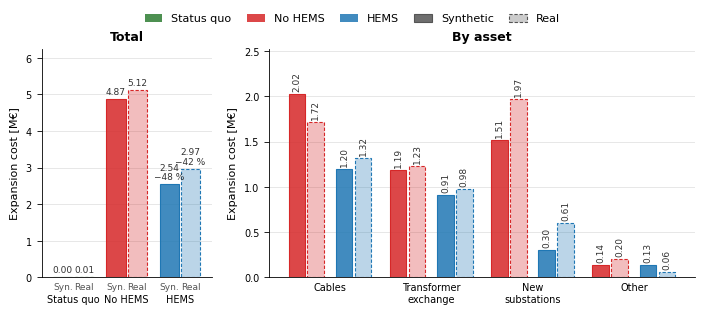

,data_source,component,inflex_cost_million_eur,flex_cost_million_eur,saving_million_eur,reduction_percent
0,Real,Cables,1.72,1.32,0.40,23.094222
1,Real,Load transfer,0.14,0.06,0.08,57.142857
2,Real,New substations,1.97,0.61,1.36,69.230769
3,Real,Transformer exchange,1.23,0.98,0.26,20.705024
4,Real,Voltage measures,0.06,0.00,0.06,100.0
5,Real,Total,5.12,2.97,2.16,42.081089
6,Synthetic,Cables,2.02,1.20,0.82,40.503773
7,Synthetic,Load transfer,0.14,0.12,0.02,14.285714
8,Synthetic,New substations,1.52,0.30,1.21,80.0
9,Synthetic,Transformer exchange,1.19,0.91,0.29,24.003357


,data_source,stage,reinforcement_150_count,reinforcement_185_count,reinforcement_240_count,reinforcement_added_capacity_ka
0,Real,status-quo,3,0,0,0.810
1,Real,INFLEX,440,27,15,132.606
2,Real,HEMS,323,21,18,100.209
3,Synthetic,status-quo,0,0,0,0.000
4,Synthetic,INFLEX,920,58,20,273.694
5,Synthetic,HEMS,623,19,4,175.585


In [6]:
grid_costs = expansion_grid_costs(context["expansion_tables_by_source"], CASES)
if grid_costs.empty:
    print("No expansion analyses of this run yet.")
else:
    costs = expansion_cost_comparison(grid_costs, stage_labels=CASES, excluded_grids=context["excluded_grids"])
    costs_by_provider = expansion_cost_comparison(
        grid_costs, stage_labels=CASES, excluded_grids=context["excluded_grids"], by="data_source"
    )
    display(costs["excluded"])
    display(costs["grids"].pivot(index="data_source", columns="stage", values=["grids", "total_cost_eur"]))
    fig = plot_expansion_cost_overview_static(
        costs["costs"],
        stage_order=CASES,
        asset_stage_order=(INFLEX, HEMS),
        color_map=CASE_COLORS,
        stage_labels=CASE_DISPLAY,
        reduction_stages=(INFLEX, HEMS),
        save_path=FIGURE_DIR / "expansion_cost_overview",
    )
    plt.show()
    display(expansion_cost_reduction_summary(costs["costs"], post_inflex_label=INFLEX, post_flex_label=HEMS))
    display(costs["reinforcements"])

### Variant: stacked totals (Paper Figure)

The total bars of the figure above without the status quo (almost no cost), each stacked by asset in shades of
the case color (cables at the bottom, *Other* at the top); each legend swatch shows the INFLEX (left) and HEMS
shade (right) of its asset. The dotted boxes are the cost saved through HEMS against INFLEX of the same grids.

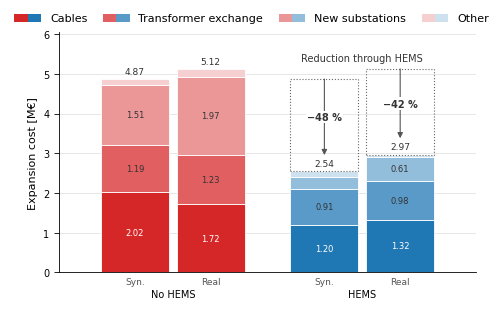

In [7]:
if not grid_costs.empty:
    fig = plot_expansion_cost_stacked_static(
        costs["costs"],
        stage_order=(INFLEX, HEMS),
        color_map=CASE_COLORS,
        stage_labels=CASE_DISPLAY,
        reduction_stages=(INFLEX, HEMS),
        save_path=FIGURE_DIR / "expansion_cost_stacked",
    )
    plt.show()

### Per provider (diagnostic)

In [8]:
if not grid_costs.empty:
    display(expansion_cost_reduction_summary(costs_by_provider["costs"], post_inflex_label=INFLEX, post_flex_label=HEMS))
    display(costs_by_provider["grids"].pivot(index="data_source", columns="stage", values=["grids", "total_cost_eur"]))

,data_source,component,inflex_cost_million_eur,flex_cost_million_eur,saving_million_eur,reduction_percent
0,Real SWF,Cables,1.40,1.10,0.30,21.45681
1,Real SWF,Load transfer,0.14,0.06,0.08,57.142857
2,Real SWF,New substations,1.97,0.61,1.36,69.230769
3,Real SWF,Transformer exchange,0.43,0.33,0.10,23.625731
4,Real SWF,Voltage measures,0.04,0.00,0.04,100.0
5,Real SWF,Total,3.98,2.10,1.88,47.316804
6,Synthetic SWF,Cables,1.38,0.82,0.56,40.491294
7,Synthetic SWF,Load transfer,0.12,0.12,0.00,0.0
8,Synthetic SWF,New substations,1.52,0.30,1.21,80.0
9,Synthetic SWF,Transformer exchange,0.46,0.31,0.14,31.83315


grids                   total_cost_eur                           
stage           HEMS INFLEX status-quo           HEMS        INFLEX   status-quo
data_source                                                                     
Real SWF        44.0   44.0       44.0   2.095138e+06  3.976862e+06  9727.000063
Real ÜZW       213.0  213.0      213.0   8.729354e+05  1.147670e+06     0.000000
Synthetic SWF   45.0   45.0       45.0   1.564726e+06  3.467150e+06     0.000000
Synthetic ÜZW  203.0  203.0      203.0   9.791489e+05  1.401958e+06     0.000000

## Cable capacity and transported current

Whether a loading difference comes from installed ampacity, from the transported peak current, or from both.

cables  grids  median_capacity_a  median_peak_current_a  median_max_loading_percent
data_source comparison_stage                                                                                     
Real        HEMS               25496    257              178.0                   23.8                        14.5
            INFLEX             25496    257              178.0                   29.6                        16.6
            status-quo         25496    257              178.0                    7.2                         4.3
Synthetic   HEMS               25470    248              142.0                   30.6                        16.8
            INFLEX             25470    248              142.0                   35.8                        20.9
            status-quo         25470    248              142.0                    9.4                         5.3

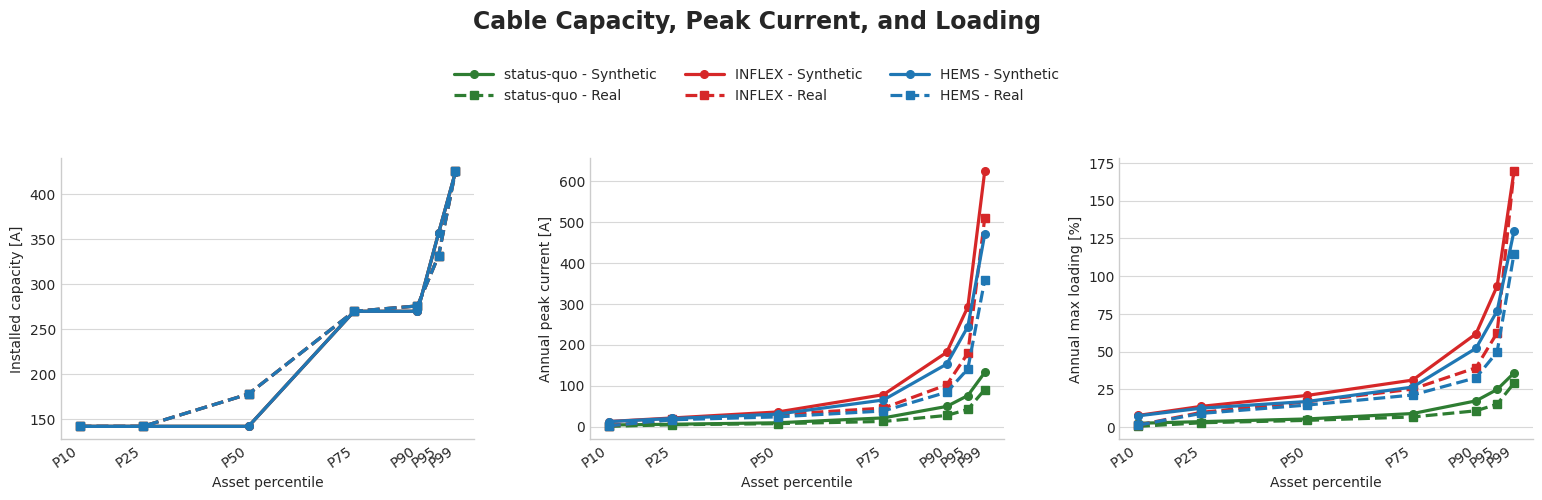

In [9]:
cables = load_cable_loading_decomposition(
    specs_by_source=context["specs_by_source"], excluded_grids=context["excluded_grids"]
)
pooled_cables = cables.assign(data_source=cables["network"])
display(
    pooled_cables.groupby(["data_source", "comparison_stage"], observed=True)
    .agg(
        cables=("asset_id", "count"),
        grids=("grid", "nunique"),
        median_capacity_a=("installed_capacity_a", "median"),
        median_peak_current_a=("max_current_a", "median"),
        median_max_loading_percent=("max_loading_percent", "median"),
    )
    .round(1)
)
plot_cable_capacity_current_loading_comparison(
    pooled_cables,
    stage_order=tuple(CASES),
    color_map=CASE_COLORS,
    save_path=FIGURE_DIR / "cable_capacity_current_loading",
)
plt.show()

## Voltage extremes

In [10]:
voltage = load_voltage_summaries_for_powerflow_comparison(
    specs_by_source=context["specs_by_source"], excluded_grids=context["excluded_grids"]
)
pooled_voltage = {}
for source, by_case in voltage.items():
    for case, frame in by_case.items():
        pooled_voltage.setdefault(group_network(source), {}).setdefault(case, []).append(frame)
pooled_voltage = {
    network: {case: pd.concat(frames, ignore_index=True) for case, frames in by_case.items()}
    for network, by_case in pooled_voltage.items()
}
plot_voltage_deviation_histogram_comparison(pooled_voltage, lower_limit=0.90, upper_limit=1.10, show=False)

## Transformer import (synthetic grids only)

The real-grid summaries store no signed transformer-import time series.

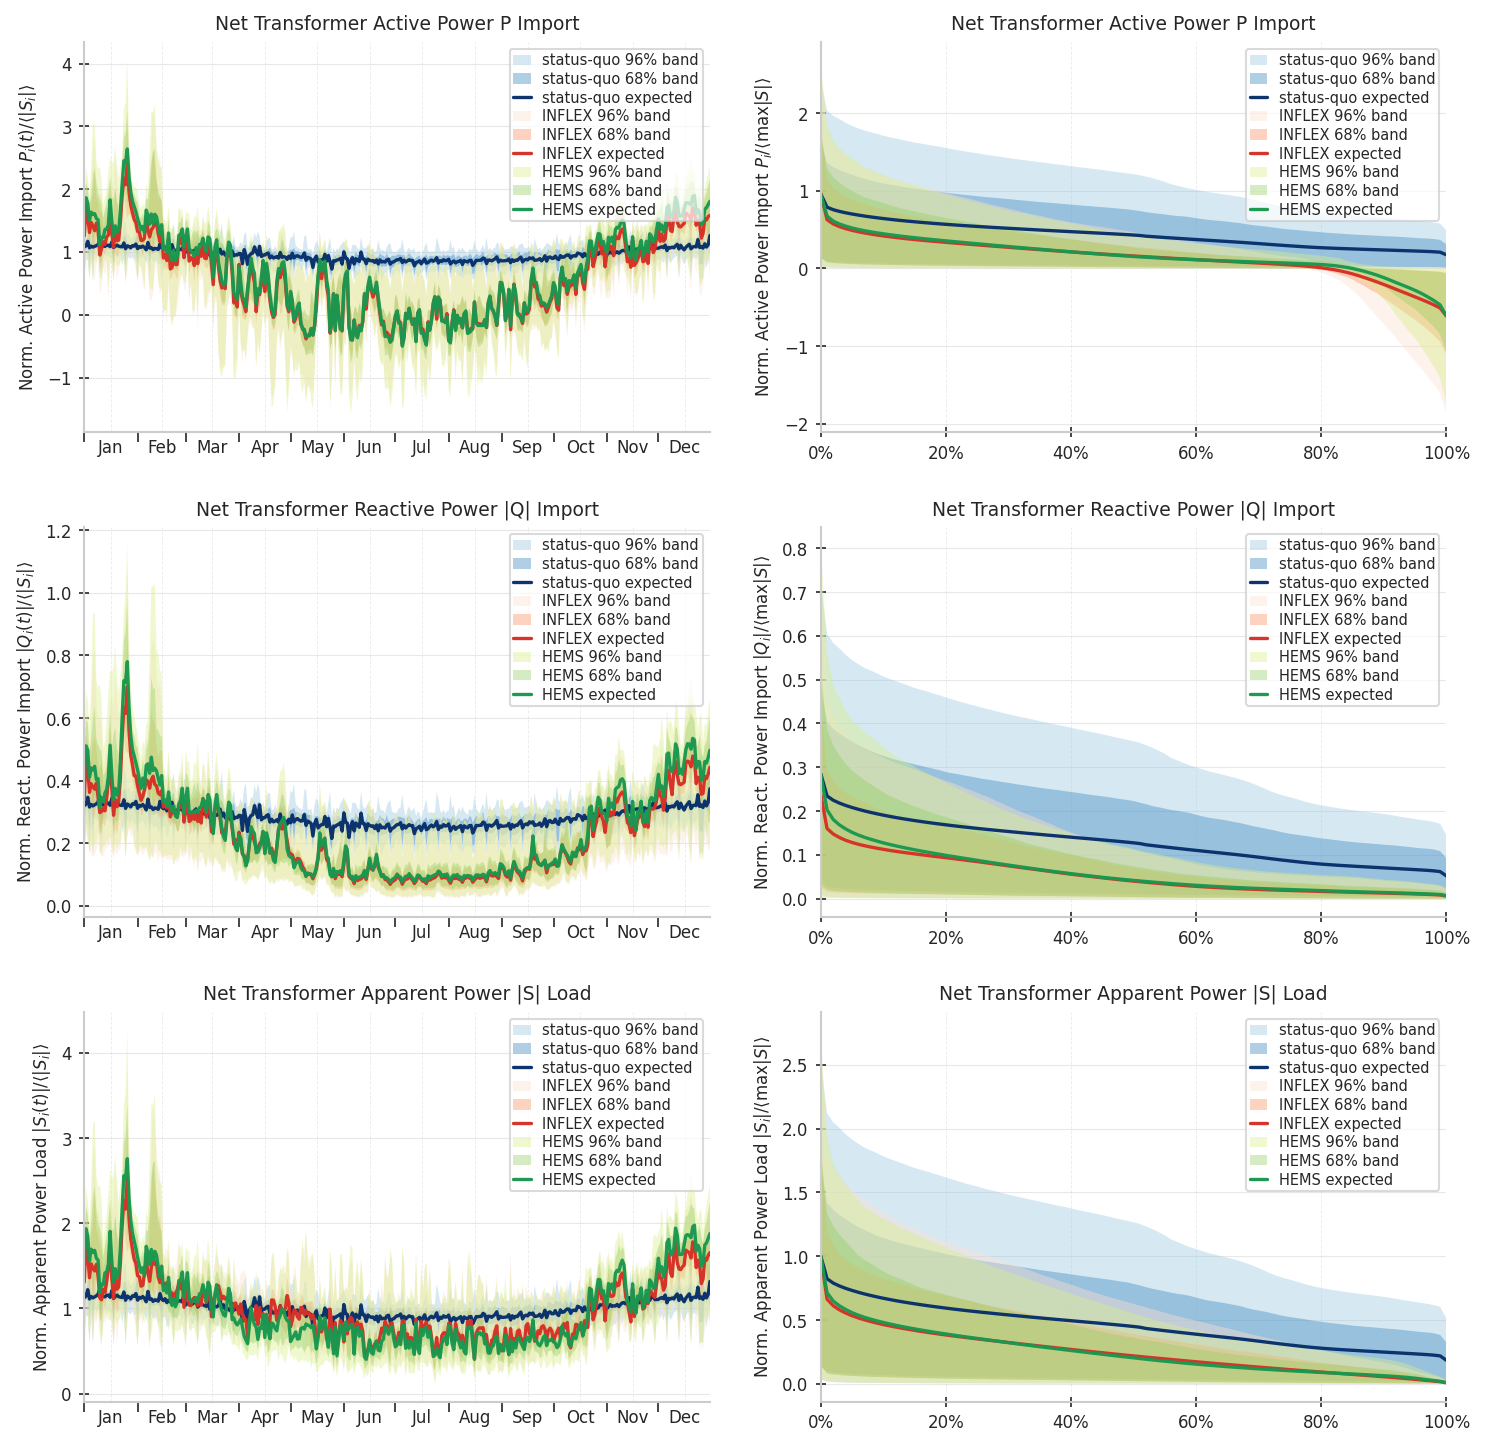

In [11]:
frames = []
for source, specs in context["specs_by_source"].items():
    if group_network(source) == "Synthetic":
        distribution = load_transformer_import_distributions_for_specs(specs)
        if not distribution.empty:
            frames.append(distribution.assign(data_source=source))
if not frames:
    print("No transformer-import time series: this run writes compact summaries only.")
else:
    fig = plot_transformer_import_distributions_matplotlib(
        pd.concat(frames, ignore_index=True), metrics=("p", "q", "s"), group_col="comparison_stage", show=False
    )
    fig.savefig(FIGURE_DIR / "transformer_import_distributions.svg", bbox_inches="tight")
    plt.show()